In [11]:
from venncy import find_2venn_distance

R, r, d = find_2venn_distance(10, 2, 0)

print(f"Area A radius: {R}, Area B radius: {r}, Distance between centers: {d}")

Area A radius: 1.7841241161527712, Area B radius: 0.7978845608028654, Distance between centers: 2.5820086523795336


<function matplotlib.pyplot.show(close=None, block=None)>

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


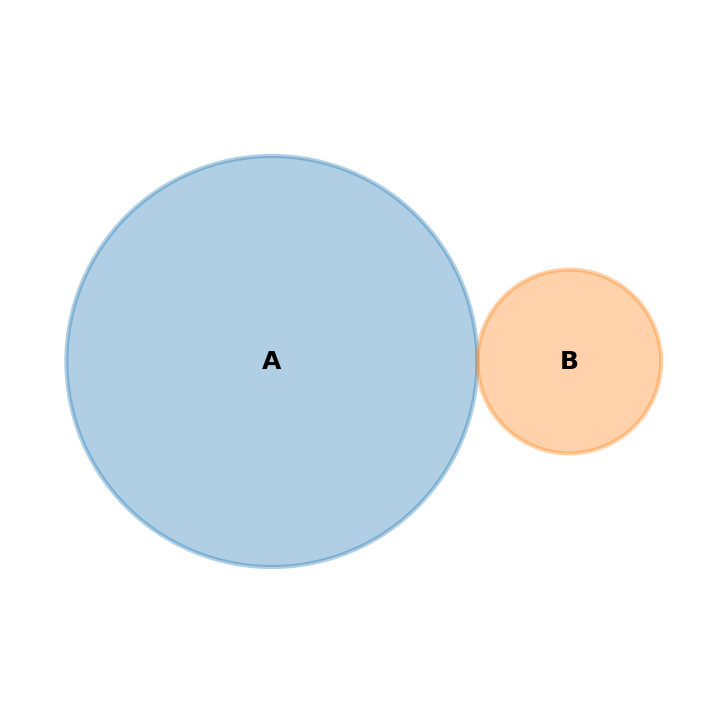

In [12]:

import matplotlib.pyplot as plt
from matplotlib.patches import Circle


# Centers (place A at -d/2, B at +d/2 on x-axis)
A = (-d/2.0, 0.0)
B = ( d/2.0, 0.0)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

# Draw circles as true data-space geometry
circA = Circle(A, R, facecolor='tab:blue',  alpha=0.35, edgecolor='tab:blue',  lw=2)
circB = Circle(B, r, facecolor='tab:orange', alpha=0.35, edgecolor='tab:orange', lw=2)
ax.add_patch(circA)
ax.add_patch(circB)

# Labels
ax.text(*A, 'A', ha='center', va='center', fontsize=12, weight='bold')
ax.text(*B, 'B', ha='center', va='center', fontsize=12, weight='bold')

# Keep 1:1 scaling so radii are visually correct
ax.set_aspect('equal', adjustable='datalim')

# Set limits with a margin so circles are fully visible
margin = 0.25 * max(R, r)
xmin = min(A[0]-R, B[0]-r) - margin
xmax = max(A[0]+R, B[0]+r) + margin
ymax = max(R, r) + margin
ax.set_xlim(xmin, xmax)
ax.set_ylim(-ymax, ymax)

ax.axis('off')
plt.show


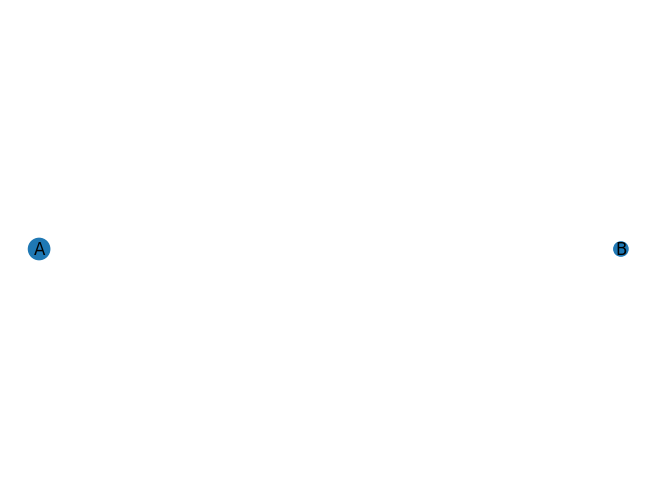

In [13]:
import networkx as nx
from pyvis.network import Network
from math import sqrt, pi

# --- Parameters (data units) ---
R, r, d = find_2venn_distance(10, 2, 0.000001)

# Convert areas to radii
R = sqrt(R / pi)
r = sqrt(r / pi)

height = 800
width = 800

# Build graph
G = nx.Graph()
G.add_nodes_from(["A", "B"])
pos = {"A": (-d/2, 0.0), "B": (d/2, 0.0)}
radii = {"A": R, "B": r}

# --- Map data-space to pixel canvas ---
margin_px = 60
usable_w = width - 2 * margin_px
usable_h = height - 2 * margin_px

xmin = min(pos["A"][0] - R, pos["B"][0] - r)
xmax = max(pos["A"][0] + R, pos["B"][0] + r)
ymin = min(-R, -r)
ymax = max(R, r)

data_w = xmax - xmin
data_h = ymax - ymin

scale = min(usable_w / data_w if data_w > 0 else usable_w,
            usable_h / data_h if data_h > 0 else usable_h)

def data_to_px(x, y):
    X = margin_px + (x - xmin) * scale
    Y = margin_px + (y - ymin) * scale
    return X, Y

# radii in pixels; vis.js 'dot' node size is diameter in pixels
radii_px = {n: radii[n] * scale for n in G.nodes}

# Convert radii to area in points for nx.draw
node_sizes = [pi * (radii_px[n] ** 2) for n in G.nodes]  # Area = π * r^2

# Stamp attributes BEFORE from_nx
for n in G.nodes:
    X, Y = data_to_px(*pos[n])
    G.nodes[n]['x'] = float(X)
    G.nodes[n]['y'] = float(Y)
    G.nodes[n]['fixed'] = True
    G.nodes[n]['physics'] = False
    G.nodes[n]['shape'] = 'dot'
    G.nodes[n]['size'] = float(radii_px[n])  # diameter = 2 * radius_px
    G.nodes[n]['label'] = n
    G.nodes[n]['borderWidth'] = 2
    G.nodes[n]['color'] = 'rgba(66,135,245,0.35)' if n == 'A' else 'rgba(255,159,64,0.35)'

# Use node_sizes for nx.draw
nx.draw(G, pos=pos, with_labels=True, node_size=node_sizes)

In [ ]:

net = Network(
    directed=False,
    select_menu=False,
    filter_menu=False,
    height=f"{height}px",
    width=f"{width}px",
    # cdn_resources="remote",  # default; use "local" only if assets are present
)

# Valid JSON options
net.set_options("""
{
  "physics": { "enabled": false },
  "interaction": { "dragNodes": false },
  "nodes": { "font": { "size": 16 } }
}
""")

net.from_nx(G)

# Avoid notebook mode; render to file
net.write_html("graph.html", notebook=False)


In [4]:
import plotly.graph_objects as go

# Define the parameters for the Venn diagram
R, r, d = find_2venn_distance(10, 2, 0)

# Define the centers of the circles
A = (-d/2.0, 0.0)
B = (d/2.0, 0.0)

# Create the figure
fig = go.Figure()

# Add the first circle
fig.add_shape(
    type="circle",
    xref="x",
    yref="y",
    x0=A[0] - R,
    y0=A[1] - R,
    x1=A[0] + R,
    y1=A[1] + R,
    line_color="blue",
    fillcolor="rgba(66,135,245,0.35)",
)

# Add the second circle
fig.add_shape(
    type="circle",
    xref="x",
    yref="y",
    x0=B[0] - r,
    y0=B[1] - r,
    x1=B[0] + r,
    y1=B[1] + r,
    line_color="orange",
    fillcolor="rgba(255,159,64,0.35)",
)

# Add labels for the circles
fig.add_trace(go.Scatter(
    x=[A[0], B[0]],
    y=[A[1], B[1]],
    text=["A", "B"],
    mode="text",
    textfont=dict(size=16, color="black")
))

# Set the layout
fig.update_layout(
    width=600,
    height=600,
    xaxis=dict(
        range=[min(A[0] - R, B[0] - r) - 1, max(A[0] + R, B[0] + r) + 1],
        zeroline=False
    ),
    yaxis=dict(
        range=[-max(R, r) - 1, max(R, r) + 1],
        zeroline=False
    ),
    showlegend=False
)

# Show the figure
fig.show()